In [1]:
import sys
sys.path.insert(0, "../Tools")

import pandas
import numpy as np
import tensorflow as tf
from pathlib import Path
from dna_affinity_data import DNAAffinityDataProcessor

In [2]:
# Initialize and process the data
processor = DNAAffinityDataProcessor(
    sequences_path="../../Data/training_seqs.txt",
    dbps_path="../../Data/training_DBPs.txt",
    affinity_path="../../Data/training_data.txt",
)
df_affinity = processor.process()

/Users/mayerunterberg/Library/Mobile Documents/com~apple~CloudDocs/Documents/Semester 2/Deep Learning for Bio/Bio Project/src/Maya/../Tools/dna_affinity_data.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(sequence=self.sequences)


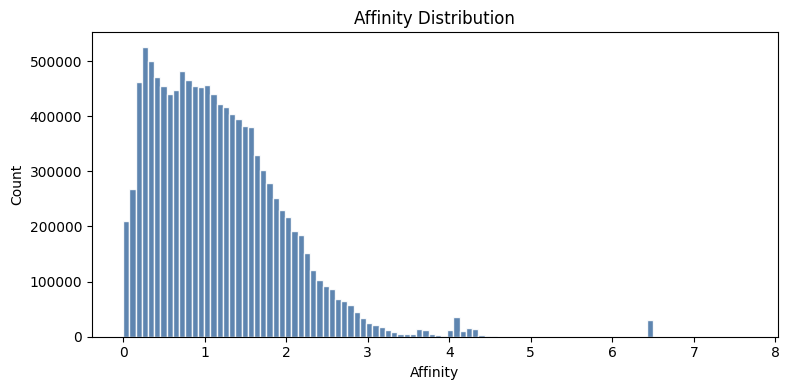

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_affinity["Affinity"], bins=100, color="#4C78A8", edgecolor="white", alpha=0.9)
plt.title("Affinity Distribution")
plt.xlabel("Affinity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Build model inputs.
dna = np.stack(df_affinity["DNA_onehot"].to_list(), axis=0).astype(np.float32)
proteins = df_affinity["Protein"].astype(str).to_numpy()
labels = df_affinity["Affinity"].to_numpy(dtype=np.float32)

# Train/validation split.
rng = np.random.default_rng(42)
indices = rng.permutation(len(labels))
split = int(0.8 * len(labels))
train_idx, val_idx = indices[:split], indices[split:]

dna_train, dna_val = dna[train_idx], dna[val_idx]
prot_train, prot_val = proteins[train_idx], proteins[val_idx]
y_train, y_val = labels[train_idx], labels[val_idx]

# Protein string lookup and embedding.
protein_lookup = tf.keras.layers.StringLookup(output_mode="int")
protein_lookup.adapt(prot_train)
protein_vocab_size = protein_lookup.vocabulary_size()

dna_input = tf.keras.Input(shape=(36, 4), name="dna_onehot")
prot_input = tf.keras.Input(shape=(), dtype=tf.string, name="protein")

x_dna = tf.keras.layers.Conv1D(32, 5, padding="same", activation="relu")(dna_input)
x_dna = tf.keras.layers.BatchNormalization()(x_dna)
x_dna = tf.keras.layers.MaxPooling1D(2)(x_dna)
x_dna = tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu")(x_dna)
x_dna = tf.keras.layers.GlobalMaxPooling1D()(x_dna)

x_prot = protein_lookup(prot_input)
x_prot = tf.keras.layers.Embedding(protein_vocab_size, 8)(x_prot)
x_prot = tf.keras.layers.Flatten()(x_prot)

x = tf.keras.layers.Concatenate()([x_dna, x_prot])
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(1, name="affinity")(x)

In [6]:
def within_tolerance(y_true, y_pred, tol=0.5):
    return tf.reduce_mean(tf.cast(tf.abs(y_true - y_pred) <= tol, tf.float32))

model = tf.keras.Model(inputs=[dna_input, prot_input], outputs=output)
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse"), within_tolerance],
)
train_ds = tf.data.Dataset.from_tensor_slices(
    ({"dna_onehot": dna_train, "protein": prot_train}, y_train)
).shuffle(2048, seed=42).batch(128).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(
    ({"dna_onehot": dna_val, "protein": prot_val}, y_val)
).batch(128).prefetch(tf.data.AUTOTUNE)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
 ]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1,
 )

Epoch 1/10
 2449/75000 ━━━━━━━━━━━━━━━━━━━━ 2:00 2ms/step - loss: 0.3594 - mae: 0.4094 - rmse: 0.5829 - within_tolerance: 0.4122

In [ ]:
# hello maya